# KDD Phase 2B — Routing Models & Evaluation
## Predicting When Stronger Models Win from Prompt Features

This notebook implements Phase 2B:
1. **Load** Phase 2A outputs and retrain Phase 1 baselines
2. **Ceiling analysis** — Elo gap oracle, noise floor
3. **XGBoost routing model** — train, tune with Optuna, evaluate
4. **SHAP analysis** — feature importance and interpretability
5. **Evaluation framework** — confusion matrices, ROC curves, bootstrap CIs, per-domain breakdown, calibration, cost curves, error analysis

**Input:** `arena_enriched_phase2.parquet`, `phase2_artifacts.pkl`
**Output:** Model files, evaluation plots, final comparison table

---
## 0. Setup

In [1]:
# Uncomment to install dependencies if needed
# !pip install -q xgboost shap optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.calibration import calibration_curve

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Setup complete.")

Setup complete.


---
## Step 2B-0: Load Data & Retrain Phase 1 Baselines

In [2]:
# Load Phase 2 enriched data
df = pd.read_parquet('arena_enriched_phase2.parquet')
with open('phase2_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

train_idx = artifacts['train_idx']
val_idx = artifacts['val_idx']
test_idx = artifacts['test_idx']
tier2_features = artifacts['tier2_features']
tier3_features = artifacts['tier3_features']

y_train = df.iloc[train_idx]['strong_model_won'].values
y_val = df.iloc[val_idx]['strong_model_won'].values
y_test = df.iloc[test_idx]['strong_model_won'].values

print(f"Loaded: {df.shape}")
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print(f"Test positive rate: {y_test.mean():.3f}")

Loaded: (79437, 122)
Train: 63549, Val: 7944, Test: 7944
Test positive rate: 0.560


### 2B-0a: Retrain TF-IDF + LR (Phase 1 Baseline)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

# Exact same configuration as Phase 1
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), max_df=0.95, min_df=5)
X_train_tfidf = tfidf.fit_transform(df.iloc[train_idx]['prompt_text'].fillna(''))
X_val_tfidf = tfidf.transform(df.iloc[val_idx]['prompt_text'].fillna(''))
X_test_tfidf = tfidf.transform(df.iloc[test_idx]['prompt_text'].fillna(''))

cat_feature_cols = ['cat_math', 'cat_coding', 'cat_creative_writing', 'cat_instruction_following']

X_train_combined = hstack([X_train_tfidf, df.iloc[train_idx][cat_feature_cols].values])
X_val_combined = hstack([X_val_tfidf, df.iloc[val_idx][cat_feature_cols].values])
X_test_combined = hstack([X_test_tfidf, df.iloc[test_idx][cat_feature_cols].values])

lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr_model.fit(X_train_combined, y_train)

lr_probs_test = lr_model.predict_proba(X_test_combined)[:, 1]
lr_preds_test = (lr_probs_test > 0.5).astype(int)
lr_acc = accuracy_score(y_test, lr_preds_test)
lr_f1 = f1_score(y_test, lr_preds_test, average='macro')
lr_auc = roc_auc_score(y_test, lr_probs_test)

print(f"TF-IDF + LR (retrained): Acc={lr_acc:.4f}  F1={lr_f1:.4f}  AUC={lr_auc:.4f}")

TF-IDF + LR (retrained): Acc=0.5465  F1=0.5020  AUC=0.5221


### 2B-0b: Compute Phase 1 Baselines

In [4]:
# Base rate
base_rate = y_test.mean()
print(f"Base rate (always predict 1): {base_rate:.4f}")

# Domain-bucket baseline: per-domain win rate from training set
domain_win_rates = df.iloc[train_idx].groupby('domain_bucket')['strong_model_won'].mean()
baseline_preds = df.iloc[test_idx]['domain_bucket'].map(domain_win_rates).round().astype(int)
baseline_acc = accuracy_score(y_test, baseline_preds)
baseline_f1 = f1_score(y_test, baseline_preds, average='macro')
print(f"Domain-Bucket Baseline: Acc={baseline_acc:.4f}  F1={baseline_f1:.4f}")

# Phase 1 DistilBERT result (hardcoded — retraining is expensive)
bert_acc = 0.5641
bert_f1 = 0.4189
print(f"DistilBERT (Phase 1, reported): Acc={bert_acc:.4f}  F1={bert_f1:.4f}")

Base rate (always predict 1): 0.5599
Domain-Bucket Baseline: Acc=0.5599  F1=0.3589
DistilBERT (Phase 1, reported): Acc=0.5641  F1=0.4189


---
## Step 2B-1: Ceiling Analysis

### 2B-1a: Oracle Baseline (Elo Gap Threshold)

In [5]:
elo_gaps = df.iloc[test_idx]['elo_domain_gap'].values
oracle_auc = roc_auc_score(y_test, elo_gaps)
print(f"Oracle AUC (Elo gap as score): {oracle_auc:.4f}")

Oracle AUC (Elo gap as score): 0.5675


### 2B-1b: Noise Floor from Tie Rate

In [6]:
tie_rate_original = 0.159  # from Phase 1 audit
print(f"Original tie rate: {tie_rate_original:.1%}")
print(f"Rough noise floor: a perfect model would still get ~{tie_rate_original/2:.1%} of battles 'wrong'")
print(f"Theoretical accuracy ceiling: ~{1 - tie_rate_original/2:.1%}")

Original tie rate: 15.9%
Rough noise floor: a perfect model would still get ~8.0% of battles 'wrong'
Theoretical accuracy ceiling: ~92.0%


---
## Step 2B-2: XGBoost Routing Model

### 2B-2a: Feature Matrix Assembly

In [7]:
import xgboost as xgb

# Define feature sets
tier1_features = [
    'prompt_word_count', 'cat_if_score',
    'cat_math', 'cat_coding', 'cat_creative_writing', 'cat_instruction_following',
    'cat_complexity', 'cat_creativity', 'cat_domain_knowledge',
    'cat_problem_solving', 'cat_real_world', 'cat_specificity', 'cat_technical_accuracy',
    'is_code', 'meta_user_tokens', 'meta_turns',
]

tier3_embedding_features = [f'emb_{i:02d}' for i in range(48)]

# Response-side features (analysis model only)
response_features = [
    'response_length_ratio', 'response_length_diff',
    'header_diff', 'list_diff', 'bold_diff', 'formatting_divergence',
]

# Domain bucket as one-hot
domain_dummies = pd.get_dummies(df['domain_bucket'], prefix='domain')
domain_dummy_cols = domain_dummies.columns.tolist()
for col in domain_dummy_cols:
    df[col] = domain_dummies[col]

# ROUTER MODEL: prompt-only features (deployable)
router_features = tier1_features + tier2_features + tier3_embedding_features + domain_dummy_cols

# ANALYSIS MODEL: includes response features (for insight)
analysis_features = router_features + response_features

print(f"Router features: {len(router_features)}")
print(f"Analysis features: {len(analysis_features)}")

Router features: 88
Analysis features: 94


### 2B-2b: Train XGBoost (Router Variant)

In [8]:
X_train = df.iloc[train_idx][router_features].values
X_val = df.iloc[val_idx][router_features].values
X_test = df.iloc[test_idx][router_features].values

# Handle class imbalance (mild: 56/44)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=router_features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=router_features)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=router_features)

params = {
    'objective': 'binary:logistic',
    'eval_metric': ['logloss', 'auc'],
    'scale_pos_weight': scale_pos_weight,
    'max_depth': 6,
    'learning_rate': 0.05,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'seed': 42,
}

model_router = xgb.train(
    params, dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=50,
)

model_router.save_model('xgb_router.json')
print("Saved: xgb_router.json")

[0]	train-logloss:0.69254	train-auc:0.55664	val-logloss:0.69285	val-auc:0.53135


[50]	train-logloss:0.67151	train-auc:0.66890	val-logloss:0.68825	val-auc:0.55730


[100]	train-logloss:0.65804	train-auc:0.71768	val-logloss:0.68771	val-auc:0.55791


[150]	train-logloss:0.64597	train-auc:0.75494	val-logloss:0.68789	val-auc:0.55745


[157]	train-logloss:0.64431	train-auc:0.75999	val-logloss:0.68795	val-auc:0.55711


Saved: xgb_router.json


### 2B-2c: Hyperparameter Tuning (Optuna, 25 Trials)

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Combine train + val for CV (keep test held out)
cv_idx = np.concatenate([train_idx, val_idx])
X_cv = df.iloc[cv_idx][router_features].values
y_cv = df.iloc[cv_idx]['strong_model_won'].values
dcv = xgb.DMatrix(X_cv, label=y_cv, feature_names=router_features)

def objective(trial):
    p = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'scale_pos_weight': scale_pos_weight,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 30),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'seed': 42,
    }
    cv_result = xgb.cv(
        p, dcv, num_boost_round=500,
        nfold=5, stratified=True, seed=42,
        early_stopping_rounds=30,
        verbose_eval=False,
    )
    return cv_result['test-auc-mean'].max()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print(f"Best CV AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best CV AUC: 0.5535
Best params: {'max_depth': 5, 'learning_rate': 0.01729950129516948, 'min_child_weight': 29, 'subsample': 0.7422308662625179, 'colsample_bytree': 0.5009832761485584, 'reg_alpha': 6.2360440903633485, 'reg_lambda': 0.025996872958732792}


In [10]:
# Retrain on full train+val with best params
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': scale_pos_weight,
    'seed': 42,
})

model_router_tuned = xgb.train(
    best_params, dcv,
    num_boost_round=500,
    verbose_eval=False,
)
model_router_tuned.save_model('xgb_router_tuned.json')

# Evaluate on test set
xgb_probs = model_router_tuned.predict(dtest)
xgb_preds = (xgb_probs > 0.5).astype(int)
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds, average='macro')
xgb_auc = roc_auc_score(y_test, xgb_probs)

print(f"\nTuned XGBoost Router: Acc={xgb_acc:.4f}  F1={xgb_f1:.4f}  AUC={xgb_auc:.4f}")


Tuned XGBoost Router: Acc=0.5331  F1=0.5311  AUC=0.5529


### 2B-2d: Train Analysis Model (with response features)

In [11]:
X_train_analysis = df.iloc[train_idx][analysis_features].values
X_val_analysis = df.iloc[val_idx][analysis_features].values
X_test_analysis = df.iloc[test_idx][analysis_features].values

dtrain_analysis = xgb.DMatrix(X_train_analysis, label=y_train, feature_names=analysis_features)
dval_analysis = xgb.DMatrix(X_val_analysis, label=y_val, feature_names=analysis_features)
dtest_analysis = xgb.DMatrix(X_test_analysis, label=y_test, feature_names=analysis_features)

model_analysis = xgb.train(
    best_params, dtrain_analysis,
    num_boost_round=1000,
    evals=[(dtrain_analysis, 'train'), (dval_analysis, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False,
)
model_analysis.save_model('xgb_analysis.json')

analysis_probs = model_analysis.predict(dtest_analysis)
analysis_preds = (analysis_probs > 0.5).astype(int)
analysis_acc = accuracy_score(y_test, analysis_preds)
analysis_f1 = f1_score(y_test, analysis_preds, average='macro')
analysis_auc = roc_auc_score(y_test, analysis_probs)

print(f"Analysis Model: Acc={analysis_acc:.4f}  F1={analysis_f1:.4f}  AUC={analysis_auc:.4f}")
print(f"Response feature lift: AUC +{analysis_auc - xgb_auc:.4f}")

Analysis Model: Acc=0.5568  F1=0.5568  AUC=0.5870
Response feature lift: AUC +0.0342


### Checkpoint 2B-2: Model Comparison

In [12]:
print(f"{'Model':<30} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print("-" * 56)
print(f"{'Base Rate (always predict 1)':<30} {base_rate:>8.4f} {'---':>8} {'0.500':>8}")
print(f"{'Domain-Bucket Baseline':<30} {baseline_acc:>8.4f} {baseline_f1:>8.4f} {'---':>8}")
print(f"{'TF-IDF + LR':<30} {lr_acc:>8.4f} {lr_f1:>8.4f} {lr_auc:>8.4f}")
print(f"{'DistilBERT (Phase 1)':<30} {bert_acc:>8.4f} {bert_f1:>8.4f} {'---':>8}")
print(f"{'XGBoost Router (tuned)':<30} {xgb_acc:>8.4f} {xgb_f1:>8.4f} {xgb_auc:>8.4f}")
print(f"{'XGBoost Analysis (oracle)':<30} {analysis_acc:>8.4f} {analysis_f1:>8.4f} {analysis_auc:>8.4f}")

Model                               Acc       F1      AUC
--------------------------------------------------------
Base Rate (always predict 1)     0.5599      ---    0.500
Domain-Bucket Baseline           0.5599   0.3589      ---
TF-IDF + LR                      0.5465   0.5020   0.5221
DistilBERT (Phase 1)             0.5641   0.4189      ---
XGBoost Router (tuned)           0.5331   0.5311   0.5529
XGBoost Analysis (oracle)        0.5568   0.5568   0.5870


---
## Step 2B-3: SHAP Analysis

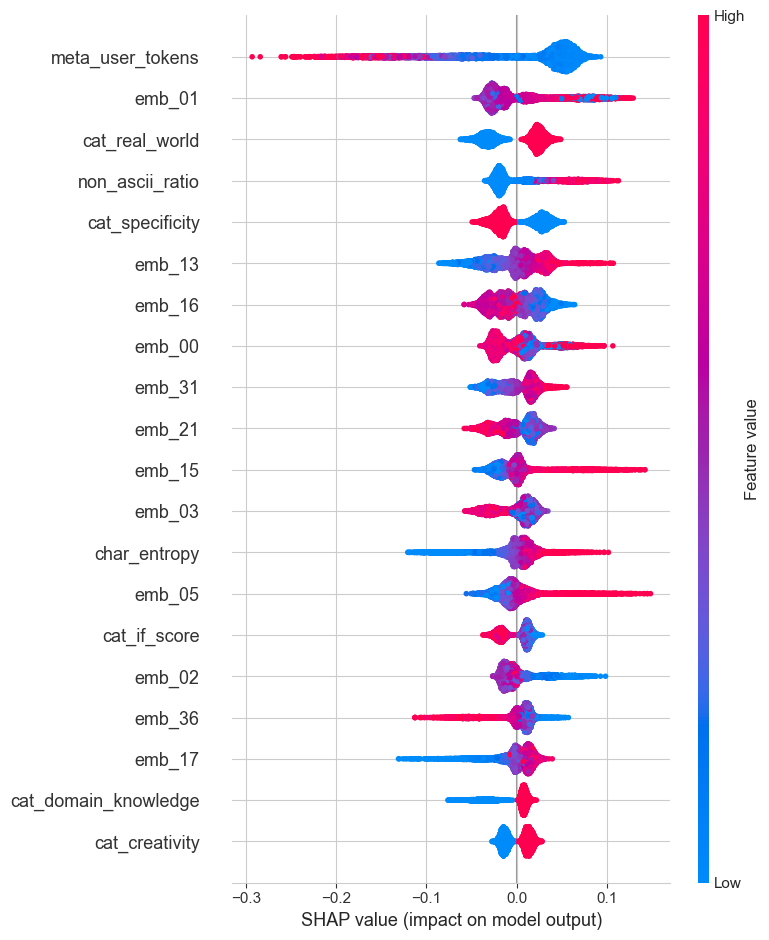

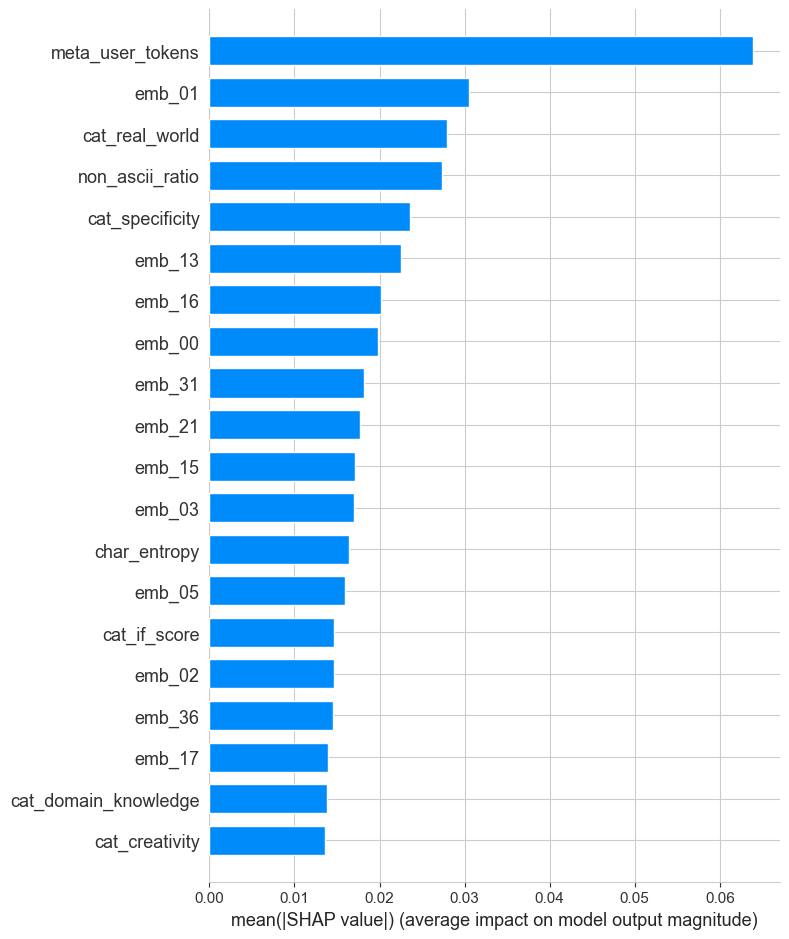

In [13]:
import shap

explainer = shap.TreeExplainer(model_router_tuned)
shap_values = explainer.shap_values(X_test)

# Beeswarm plot
shap.summary_plot(shap_values, X_test, feature_names=router_features, max_display=20, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot
shap.summary_plot(shap_values, X_test, feature_names=router_features,
                  plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 2B-3a: Dependence Plots for Top Features

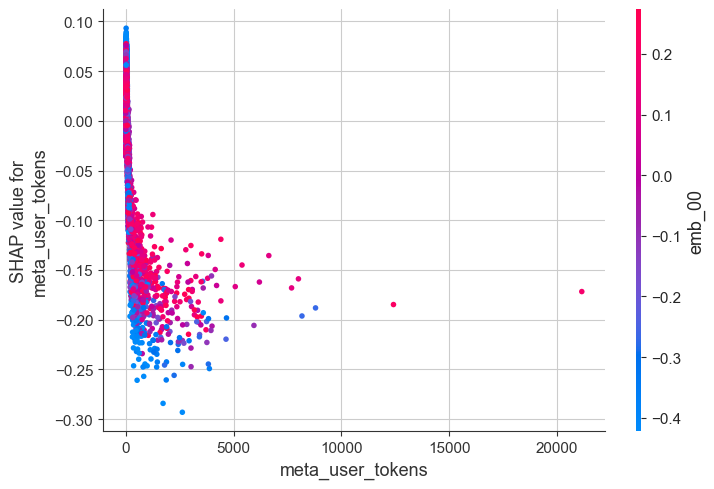

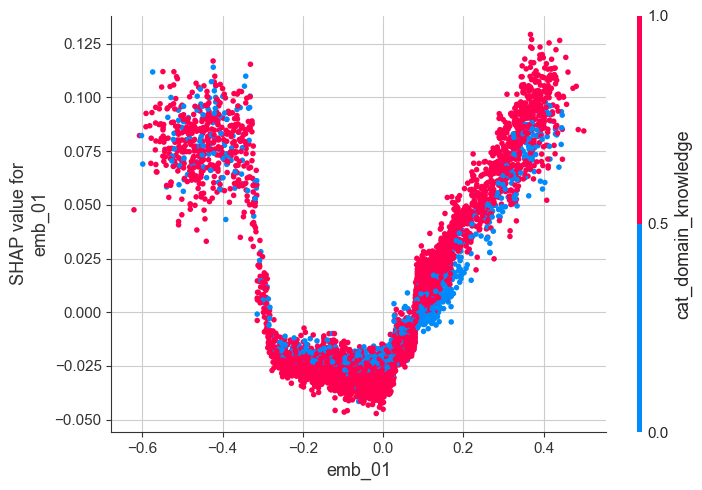

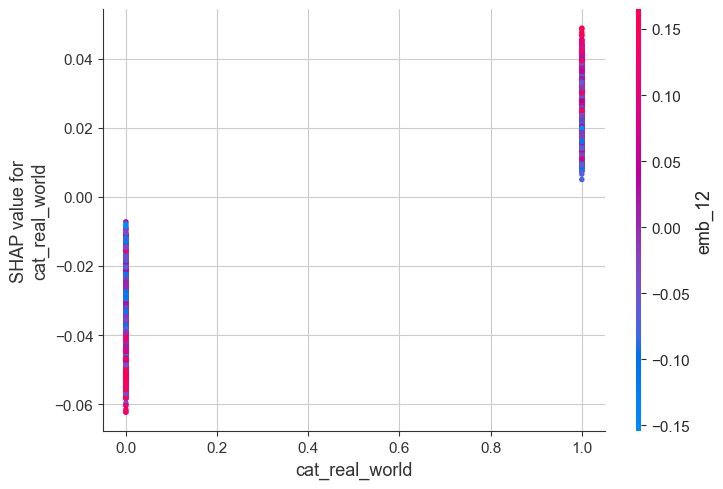

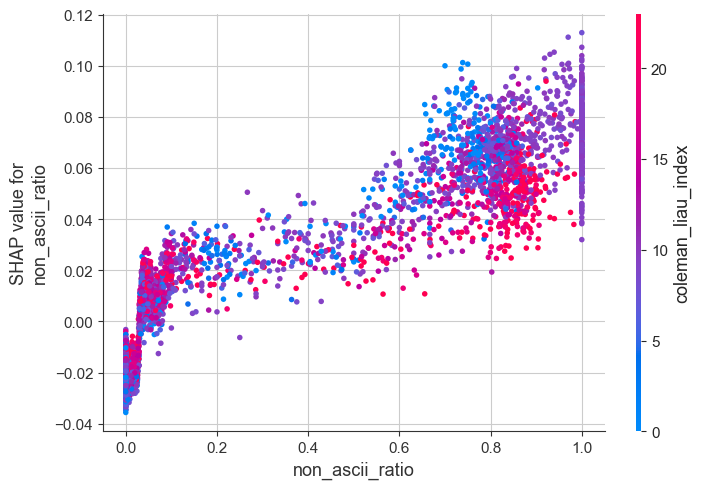

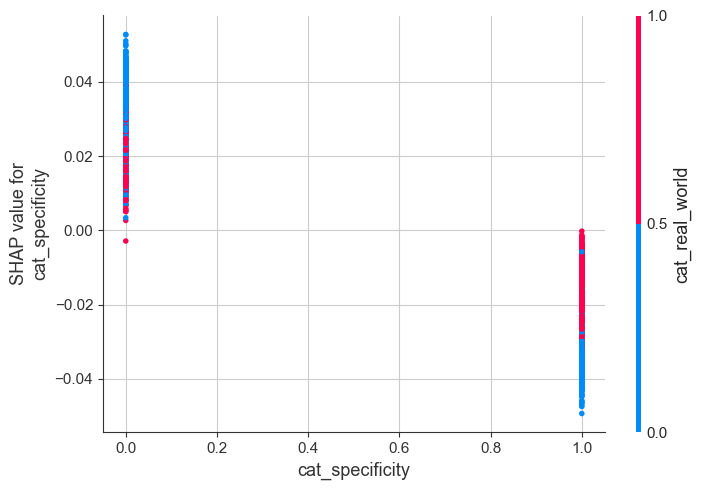

In [14]:
top_features_idx = np.argsort(-np.abs(shap_values).mean(axis=0))[:5]

for idx in top_features_idx:
    feat_name = router_features[idx]
    shap.dependence_plot(idx, shap_values, X_test, feature_names=router_features, show=False)
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feat_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 2B-4: Evaluation Framework

### 2B-4a: Confusion Matrices

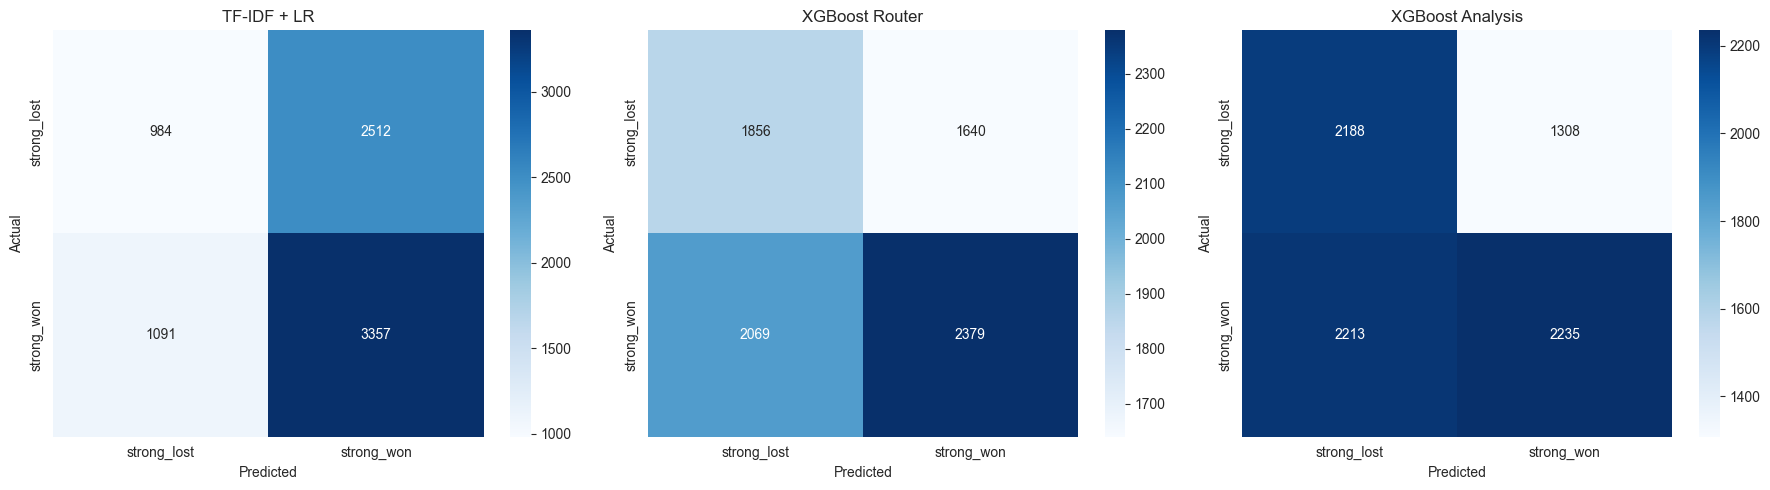

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['strong_lost', 'strong_won']

for ax, (name, preds) in zip(axes, [
    ('TF-IDF + LR', lr_preds_test),
    ('XGBoost Router', xgb_preds),
    ('XGBoost Analysis', analysis_preds),
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### 2B-4b: ROC Curves

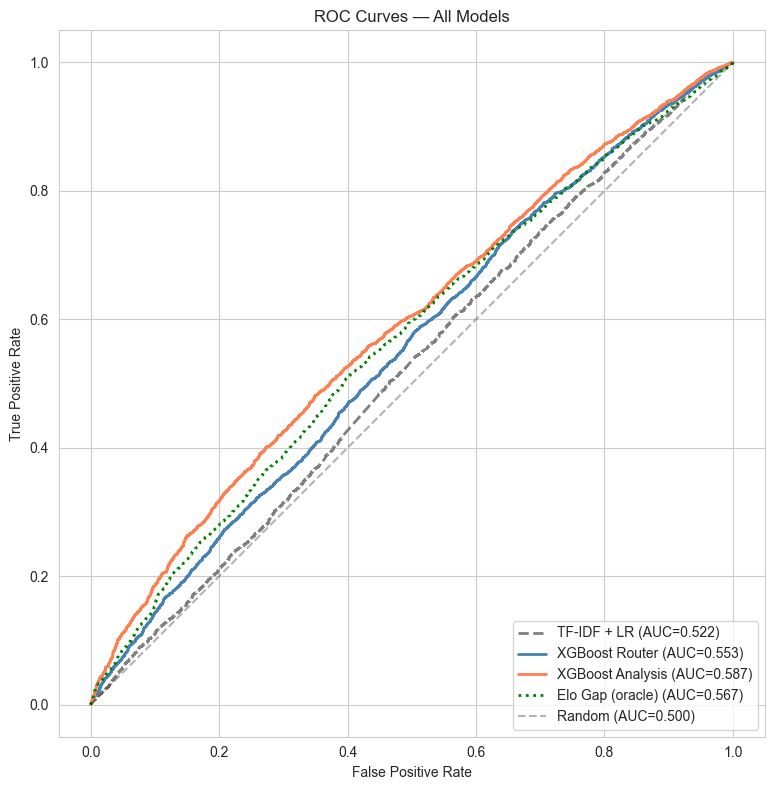

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

for name, probs, color, ls in [
    ('TF-IDF + LR', lr_probs_test, 'gray', '--'),
    ('XGBoost Router', xgb_probs, 'steelblue', '-'),
    ('XGBoost Analysis', analysis_probs, 'coral', '-'),
    ('Elo Gap (oracle)', elo_gaps, 'green', ':'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
            label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

### 2B-4c: Bootstrap Confidence Intervals

In [17]:
def bootstrap_metric(y_true, y_probs, metric_fn, n_iter=1000, seed=42):
    """Compute bootstrap 95% CI for a metric."""
    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_iter):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_probs[idx]))
    scores = np.array(scores)
    return np.median(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print("--- 95% Bootstrap Confidence Intervals (1000 iterations) ---")
print(f"{'Model':<25} {'AUC':>8}   {'95% CI':>16}")
print("-" * 55)

for name, probs in [
    ('TF-IDF + LR', lr_probs_test),
    ('XGBoost Router', xgb_probs),
    ('XGBoost Analysis', analysis_probs),
]:
    median_auc, lo, hi = bootstrap_metric(y_test, probs, roc_auc_score)
    print(f"{name:<25} {median_auc:>8.4f}   [{lo:.4f}, {hi:.4f}]")

--- 95% Bootstrap Confidence Intervals (1000 iterations) ---
Model                          AUC             95% CI
-------------------------------------------------------


TF-IDF + LR                 0.5225   [0.5089, 0.5351]


XGBoost Router              0.5528   [0.5402, 0.5655]


XGBoost Analysis            0.5870   [0.5753, 0.5993]


### 2B-4d: Per-Domain Performance Breakdown

In [18]:
print(f"\n{'Domain':<20} {'Model':<20} {'Acc':>8} {'AUC':>8} {'n':>6}")
print("-" * 65)

for domain in ['code', 'math_science', 'creative_writing', 'chat']:
    mask = df.iloc[test_idx]['domain_bucket'].values == domain
    n = mask.sum()
    yt = y_test[mask]

    for name, probs in [('TF-IDF + LR', lr_probs_test), ('XGBoost Router', xgb_probs)]:
        preds = (probs[mask] > 0.5).astype(int)
        acc = accuracy_score(yt, preds)
        auc = roc_auc_score(yt, probs[mask]) if len(np.unique(yt)) > 1 else float('nan')
        print(f"{domain:<20} {name:<20} {acc:>8.4f} {auc:>8.4f} {n:>6}")


Domain               Model                     Acc      AUC      n
-----------------------------------------------------------------
code                 TF-IDF + LR            0.5427   0.5191   2121
code                 XGBoost Router         0.5200   0.5493   2121
math_science         TF-IDF + LR            0.5156   0.5017    514
math_science         XGBoost Router         0.5117   0.5279    514
creative_writing     TF-IDF + LR            0.5923   0.5672    574
creative_writing     XGBoost Router         0.5279   0.5299    574
chat                 TF-IDF + LR            0.5459   0.5193   4735
chat                 XGBoost Router         0.5419   0.5594   4735


### 2B-4e: Confidence Calibration (Reliability Diagrams)

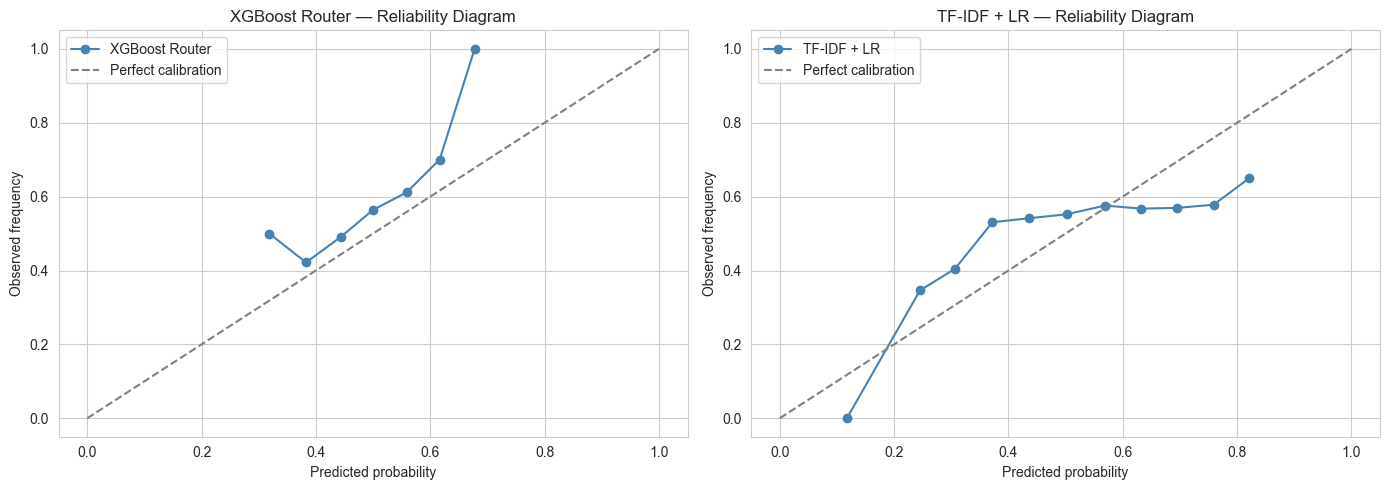

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, probs) in zip(axes, [('XGBoost Router', xgb_probs), ('TF-IDF + LR', lr_probs_test)]):
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=15, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', color='steelblue', label=name)
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.set_title(f'{name} — Reliability Diagram')
    ax.legend()

plt.tight_layout()
plt.savefig('calibration_plots.png', dpi=150)
plt.show()

### 2B-4f: Cost-Performance Curves

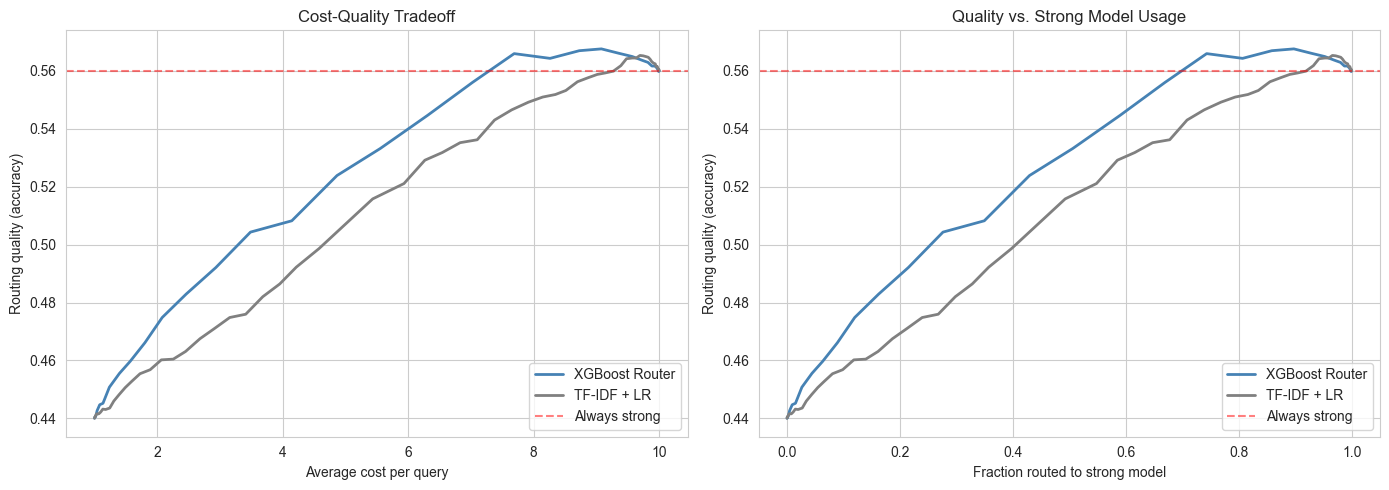


Recommended operating point:
  Threshold: 0.44
  Quality: 0.5675
  Fraction routed to strong: 89.75%
  Cost: 9.08 (vs 10.00 for always-strong)


In [20]:
def compute_routing_curve(y_true, probs, cost_strong=10.0, cost_weak=1.0):
    """Sweep routing threshold and compute quality/cost tradeoff."""
    thresholds = np.linspace(0, 1, 101)
    results = []

    for theta in thresholds:
        route_to_strong = probs > theta
        frac_strong = route_to_strong.mean()

        correct_strong = (y_true[route_to_strong] == 1).sum() if route_to_strong.any() else 0
        correct_weak = (y_true[~route_to_strong] == 0).sum() if (~route_to_strong).any() else 0
        quality = (correct_strong + correct_weak) / len(y_true)

        cost = frac_strong * cost_strong + (1 - frac_strong) * cost_weak

        results.append({
            'threshold': theta,
            'frac_strong': frac_strong,
            'quality': quality,
            'cost': cost,
        })

    return pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs, color in [
    ('XGBoost Router', xgb_probs, 'steelblue'),
    ('TF-IDF + LR', lr_probs_test, 'gray'),
]:
    curve = compute_routing_curve(y_test, probs)
    axes[0].plot(curve['cost'], curve['quality'], '-', color=color, label=name, linewidth=2)
    axes[1].plot(curve['frac_strong'], curve['quality'], '-', color=color, label=name, linewidth=2)

axes[0].axhline(base_rate, color='red', linestyle='--', alpha=0.5, label='Always strong')
axes[0].set_xlabel('Average cost per query')
axes[0].set_ylabel('Routing quality (accuracy)')
axes[0].set_title('Cost-Quality Tradeoff')
axes[0].legend()

axes[1].axhline(base_rate, color='red', linestyle='--', alpha=0.5, label='Always strong')
axes[1].set_xlabel('Fraction routed to strong model')
axes[1].set_ylabel('Routing quality (accuracy)')
axes[1].set_title('Quality vs. Strong Model Usage')
axes[1].legend()

plt.tight_layout()
plt.savefig('cost_performance_curves.png', dpi=150)
plt.show()

# Recommended operating point
curve = compute_routing_curve(y_test, xgb_probs)
best_row = curve.loc[curve['quality'].idxmax()]
print(f"\nRecommended operating point:")
print(f"  Threshold: {best_row['threshold']:.2f}")
print(f"  Quality: {best_row['quality']:.4f}")
print(f"  Fraction routed to strong: {best_row['frac_strong']:.2%}")
print(f"  Cost: {best_row['cost']:.2f} (vs {10.0:.2f} for always-strong)")

### 2B-4g: Prompt Difficulty Estimation

In [21]:
df_test = df.iloc[test_idx].copy()
df_test['xgb_prob'] = xgb_probs

df_test['difficulty'] = pd.cut(
    df_test['xgb_prob'],
    bins=[0, 0.4, 0.6, 1.0],
    labels=['hard_for_strong', 'ambiguous', 'easy_for_strong']
)

print("--- Prompt difficulty distribution ---")
print(df_test['difficulty'].value_counts())

for diff in ['easy_for_strong', 'ambiguous', 'hard_for_strong']:
    subset = df_test[df_test['difficulty'] == diff]
    print(f"\n--- {diff} (n={len(subset)}) ---")
    print(f"  Actual win rate: {subset['strong_model_won'].mean():.3f}")
    print(f"  Mean word count: {subset['prompt_word_count'].mean():.0f}")
    print(f"  Mean constraints: {subset['total_constraints'].mean():.1f}")
    print(f"  Mean readability: {subset['flesch_kincaid_grade'].mean():.1f}")
    print(f"  Domain dist: {subset['domain_bucket'].value_counts(normalize=True).round(2).to_dict()}")
    print(f"  Code fraction: {subset['is_code'].mean():.2f}")

--- Prompt difficulty distribution ---
difficulty
ambiguous          7576
easy_for_strong     209
hard_for_strong     159
Name: count, dtype: int64

--- easy_for_strong (n=209) ---
  Actual win rate: 0.703
  Mean word count: 8
  Mean constraints: 0.0
  Mean readability: 6.2
  Domain dist: {'chat': 0.67, 'code': 0.21, 'creative_writing': 0.08, 'math_science': 0.04}
  Code fraction: 0.21

--- ambiguous (n=7576) ---
  Actual win rate: 0.559
  Mean word count: 41
  Mean constraints: 0.4
  Mean readability: 7.4
  Domain dist: {'chat': 0.59, 'code': 0.27, 'creative_writing': 0.07, 'math_science': 0.06}
  Code fraction: 0.27

--- hard_for_strong (n=159) ---
  Actual win rate: 0.428
  Mean word count: 42
  Mean constraints: 0.4
  Mean readability: 8.2
  Domain dist: {'chat': 0.66, 'math_science': 0.16, 'code': 0.15, 'creative_writing': 0.03}
  Code fraction: 0.15


### 2B-4h: Error Analysis

In [22]:
df_test['xgb_pred'] = xgb_preds
df_test['correct'] = (df_test['xgb_pred'] == df_test['strong_model_won']).astype(int)

# False positives: predicted strong_won=1, actually 0
fp = df_test[(df_test['xgb_pred'] == 1) & (df_test['strong_model_won'] == 0)]
# False negatives: predicted strong_won=0, actually 1
fn = df_test[(df_test['xgb_pred'] == 0) & (df_test['strong_model_won'] == 1)]

print(f"False positives (wasted strong model): {len(fp)} ({len(fp)/len(df_test):.1%})")
print(f"False negatives (needed strong, got weak): {len(fn)} ({len(fn)/len(df_test):.1%})")

print(f"\n--- Sample False Negatives (should have routed to strong) ---")
for _, row in fn.sample(min(10, len(fn)), random_state=42).iterrows():
    prompt_preview = row['prompt_text'][:150].replace('\n', ' ')
    print(f"  [{row['domain_bucket']}] p={row['xgb_prob']:.3f} | {prompt_preview}...")

print(f"\n--- Sample False Positives (wasted strong model) ---")
for _, row in fp.sample(min(10, len(fp)), random_state=42).iterrows():
    prompt_preview = row['prompt_text'][:150].replace('\n', ' ')
    print(f"  [{row['domain_bucket']}] p={row['xgb_prob']:.3f} | {prompt_preview}...")

False positives (wasted strong model): 1640 (20.6%)
False negatives (needed strong, got weak): 2069 (26.0%)

--- Sample False Negatives (should have routed to strong) ---
  [code] p=0.439 | The next code throws segmentation fault. Provide full code after fix:  .global	compute_char_repeats, parse_lines  .section .text compute_char_repeats:...
  [code] p=0.427 | can you make me the code. I have 5 frames named Inv1, Inv2, Inv3, Inv4, inv5. I also have 5 image buttons named Tower1Button. Tower2Button, Tower3Butt...
  [chat] p=0.445 | . Americans believe that ______ is the most appropriate procedure for making public- policy decisions. a. a corporatist arrangement b. a referendum or...
  [code] p=0.499 | Привет! Мне нужно составить модель для предсказывания эффективности ингибитора коррозии из четвертичных аммонийных солей. Как ты посоветуешь это сдела...
  [chat] p=0.497 | ти експерт з сервіс дизайну з 15-ти річним стажем. твоя спеціалізація - юзер персони. треба допомога з такою ситуацією

### 2B-4i: Full Comparison Table

In [23]:
results = pd.DataFrame({
    'Model': [
        'Base Rate (always predict 1)',
        'Domain-Bucket Baseline',
        'TF-IDF + LR',
        'DistilBERT (Phase 1)',
        'XGBoost Router (tuned)',
        'XGBoost Analysis (oracle)',
    ],
    'Accuracy': [base_rate, baseline_acc, lr_acc, bert_acc, xgb_acc, analysis_acc],
    'Macro F1': ['---', f'{baseline_f1:.4f}', f'{lr_f1:.4f}', f'{bert_f1:.4f}',
                 f'{xgb_f1:.4f}', f'{analysis_f1:.4f}'],
    'AUC-ROC': ['0.5000', '---', f'{lr_auc:.4f}', '---',
                f'{xgb_auc:.4f}', f'{analysis_auc:.4f}'],
})
print("\n=== Final Model Comparison ===")
print(results.to_string(index=False))


=== Final Model Comparison ===
                       Model  Accuracy Macro F1 AUC-ROC
Base Rate (always predict 1)  0.559919      ---  0.5000
      Domain-Bucket Baseline  0.559919   0.3589     ---
                 TF-IDF + LR  0.546450   0.5020  0.5221
        DistilBERT (Phase 1)  0.564100   0.4189     ---
      XGBoost Router (tuned)  0.533107   0.5311  0.5529
   XGBoost Analysis (oracle)  0.556772   0.5568  0.5870


---
## Phase 2B Complete

**Model artifacts:**
- `xgb_router.json` — initial XGBoost router
- `xgb_router_tuned.json` — tuned XGBoost router (best Optuna params)
- `xgb_analysis.json` — XGBoost analysis model (with response features)

**Evaluation plots:**
- `shap_beeswarm.png`, `shap_bar.png`, `shap_dependence_*.png`
- `confusion_matrices.png`
- `roc_curves.png`
- `calibration_plots.png`
- `cost_performance_curves.png`

**Key questions answered:**
1. How much do Tier 2/3 features improve over Phase 1? (bootstrap CIs)
2. What fraction of signal comes from prompt vs. response features? (router vs analysis AUC gap)
3. Which prompt properties most strongly predict strong model wins? (SHAP)
4. Does routing differ across domains/languages? (per-domain breakdown)
5. What is the achievable cost-quality tradeoff? (cost curves + operating point)
6. Where does the router fail? (error analysis)